# Модель риска при беременности

Прогноз `RiskLevel`: `low risk` / `mid risk` / `high risk`.

Метрика отбора — **f1_macro** (три класса, mid и high нельзя потерять в среднем).  
Дополнительно смотрим recall mid и high.

Подробный EDA: https://github.com/NexPG/risk-of-pregnancy/blob/main/code/EDA.ipynb  
Сравнение моделей: https://github.com/NexPG/risk-of-pregnancy/blob/main/code/trainer.ipynb

In [7]:
%matplotlib inline

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
    recall_score,
    precision_score,
    accuracy_score,
)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

sns.set_theme(style="whitegrid")

DATA = Path("data/Maternal Health Risk Data Set.xlsx")
if not DATA.exists():
    DATA.parent.mkdir(exist_ok=True)
    url = "https://github.com/NexPG/risk-of-pregnancy/raw/main/data/Maternal%20Health%20Risk%20Data%20Set.xlsx"
    import urllib.request
    urllib.request.urlretrieve(url, DATA)

df = pd.read_excel(DATA)
print(df.shape)
df.head()

(1014, 7)


c:\Users\user\miniconda3\envs\main\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


## Данные

6 числовых признаков + таргет. Пропусков нет.  
В сырой таблице 1014 строк, из них **562 полных дубля** (строка совпадает по всем полям).  
Оставляем уникальные профили — иначе CV и test смотрят одни и те же копии, метрики фальшивы.

Единственный явный артефакт: `HeartRate = 7` (живьём так не бывает). Выкидываем `HeartRate < 40`.

Почему так, цифры и графики — в [EDA.ipynb](https://github.com/NexPG/risk-of-pregnancy/blob/main/code/EDA.ipynb).

In [8]:
print("исходно:", df.shape, "дублей:", df.duplicated().sum())
print(df["RiskLevel"].value_counts(), "\n")

clean = df.drop_duplicates().copy()
print("после дублей:", clean.shape)

print(clean.loc[clean["HeartRate"] < 40, ["Age", "HeartRate", "RiskLevel"]])
clean = clean[clean["HeartRate"] >= 40].reset_index(drop=True)
print("после фильтра HR:", clean.shape)
print(clean["RiskLevel"].value_counts())

исходно: (1014, 7) дублей: 562
RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64 

после дублей: (452, 7)
     Age  HeartRate RiskLevel
499   16          7  low risk
после фильтра HR: (451, 7)
RiskLevel
low risk     233
high risk    112
mid risk     106
Name: count, dtype: int64


## Train / test

80/20, стратификация, `random_state=42` — тот же сплит, что в EDA.
Пишем на диск, дальше читаем только эти файлы.

In [9]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    clean, test_size=0.2, stratify=clean["RiskLevel"], random_state=42
)

Path("data").mkdir(exist_ok=True)
train_df.to_csv("data/train.csv", index=False)
test_df.to_csv("data/test.csv", index=False)

train_df = pd.read_csv("data/train.csv")
test_df  = pd.read_csv("data/test.csv")

def show_balance(name, data):
    vc = data["RiskLevel"].value_counts()
    pct = data["RiskLevel"].value_counts(normalize=True) * 100
    print(f"\n{name}: {len(data)}")
    for cls, n in vc.items():
        print(f"  {cls:10s} {n:3d}  ({pct[cls]:5.1f}%)")

show_balance("train", train_df)
show_balance("test", test_df)

X_train = train_df.drop(columns=["RiskLevel"])
y_train = train_df["RiskLevel"]
X_test  = test_df.drop(columns=["RiskLevel"])
y_test  = test_df["RiskLevel"]
LABELS = ["low risk", "mid risk", "high risk"]


train: 360
  low risk   186  ( 51.7%)
  high risk   89  ( 24.7%)
  mid risk    85  ( 23.6%)

test: 91
  low risk    47  ( 51.6%)
  high risk   23  ( 25.3%)
  mid risk    21  ( 23.1%)


## Модель

В [trainer.ipynb](https://github.com/NexPG/risk-of-pregnancy/blob/main/code/trainer.ipynb) на одном и том же train и 5-fold StratifiedKFold сравнили 6 моделей + стек. Гиперпараметры подбирали Grid/Random search, метрика отбора — f1_macro. OOF после поиска:

| модель | OOF f1_macro | recall mid | recall high |
|---|---|---|---|
| Logistic Regression | 0.60 | 0.32 | 0.63 |
| SVM RBF | 0.69 | 0.40 | 0.83 |
| Decision Tree | 0.67 | 0.35 | 0.79 |
| Random Forest | 0.68 | 0.32 | 0.87 |
| XGBoost | 0.69 | 0.40 | 0.83 |
| MLP | 0.62 | 0.28 | 0.71 |
| стек SVM+RF+XGB | ~0.67 | 0.34 | 0.82 |

SVM и XGB лучшие и почти равны. Берём **SVM**: то же качество, модель проще, CV стабильнее (`0.676 ± 0.017`).

Параметры из поиска в trainer: `kernel='rbf', C=100, gamma=0.03, class_weight='balanced'`.

In [10]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(
        kernel="rbf",
        C=100,
        gamma=0.03,
        class_weight="balanced",
        random_state=42,
    )),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_tr_oof = cross_val_predict(model, X_train, y_train, cv=cv)

model.fit(X_train, y_train)
y_te = model.predict(X_test)

## Метрики и матрицы

Train — OOF с 5-fold CV (модель не видела строку, по которой предсказывает).  
Test — один раз на `data/test.csv`.

In [11]:
def dump(name, y_true, y_pred):
    print("=" * 50, name)
    print(f"accuracy : {accuracy_score(y_true, y_pred):.3f}")
    print(f"f1_macro : {f1_score(y_true, y_pred, average='macro'):.3f}")
    print("recall   :", dict(zip(LABELS, recall_score(y_true, y_pred, labels=LABELS, average=None).round(3))))
    print("precision:", dict(zip(LABELS, precision_score(y_true, y_pred, labels=LABELS, average=None).round(3))))
    print()
    print(classification_report(y_true, y_pred, labels=LABELS, digits=3))

dump("TRAIN (OOF)", y_train, y_tr_oof)
dump("TEST", y_test, y_te)

================================================== TRAIN (OOF)
accuracy : 0.725
f1_macro : 0.680
recall   : {'low risk': np.float64(0.839), 'mid risk': np.float64(0.412), 'high risk': np.float64(0.787)}
precision: {'low risk': np.float64(0.78), 'mid risk': np.float64(0.507), 'high risk': np.float64(0.769)}

              precision    recall  f1-score   support

    low risk      0.780     0.839     0.808       186
    mid risk      0.507     0.412     0.455        85
   high risk      0.769     0.787     0.778        89

    accuracy                          0.725       360
   macro avg      0.685     0.679     0.680       360
weighted avg      0.713     0.725     0.717       360

================================================== TEST
accuracy : 0.648
f1_macro : 0.584
recall   : {'low risk': np.float64(0.809), 'mid risk': np.float64(0.238), 'high risk': np.float64(0.696)}
precision: {'low risk': np.float64(0.679), 'mid risk': np.float64(0.357), 'high risk': np.float64(0.762)}

       

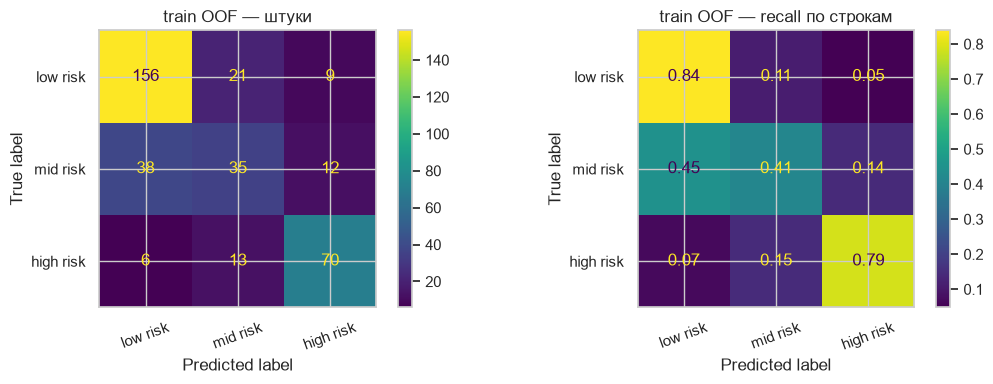

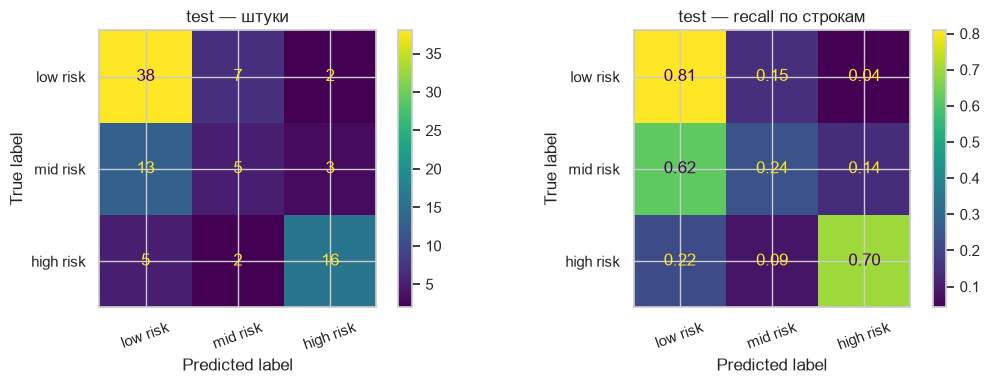

In [12]:
def show_cm(y_true, y_pred, title):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, labels=LABELS, ax=axes[0], xticks_rotation=20
    )
    axes[0].set_title(title + " — штуки")
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, labels=LABELS, normalize="true",
        values_format=".2f", ax=axes[1], xticks_rotation=20
    )
    axes[1].set_title(title + " — recall по строкам")
    plt.tight_layout()
    plt.show()

show_cm(y_train, y_tr_oof, "train OOF")
show_cm(y_test, y_te, "test")

## Доверительные интервалы на тесте

Тест маленький (91 строка, mid = 21), точечная оценка прыгает.  
Ниже 95% интервал бутстрэпом по тестовым предсказаниям.

In [13]:
rng = np.random.default_rng(42)
n_boot = 2000
y_true = np.asarray(y_test)
y_pred = np.asarray(y_te)

def metrics_pack(yt, yp):
    return {
        "accuracy": accuracy_score(yt, yp),
        "f1_macro": f1_score(yt, yp, average="macro"),
        **{f"recall_{c}": r for c, r in zip(
            LABELS, recall_score(yt, yp, labels=LABELS, average=None)
        )},
    }

point = metrics_pack(y_true, y_pred)
keys = list(point)
boots = {k: [] for k in keys}

for _ in range(n_boot):
    idx = rng.integers(0, len(y_true), size=len(y_true))
    m = metrics_pack(y_true[idx], y_pred[idx])
    for k in keys:
        boots[k].append(m[k])

rows = []
for k in keys:
    lo, hi = np.percentile(boots[k], [2.5, 97.5])
    rows.append({
        "метрика": k,
        "точка": point[k],
        "95% CI low": lo,
        "95% CI high": hi,
    })

ci = pd.DataFrame(rows).round(3)
display(ci)

,метрика,точка,95% CI low,95% CI high
0,accuracy,0.648,0.549,0.747
1,f1_macro,0.584,0.483,0.683
2,recall_low risk,0.809,0.694,0.918
3,recall_mid risk,0.238,0.059,0.435
4,recall_high risk,0.696,0.500,0.882


## Выводы

Задача — 3 класса риска по 6 измерениям.

**Данные.** Сырых 1014 строк, 562 полных дубля. Уникальных после фильтра пульса 7 осталось 451. Дубли убрали: иначе одна и та же строка попадает и в train, и в test, метрики надуваются. Подробности: https://github.com/NexPG/risk-of-pregnancy/blob/main/code/EDA.ipynb

**Модель.** На одном CV сравнили logreg, SVM, дерево, RF, XGB, MLP и стек. Лучшие — SVM и XGB (OOF f1_macro ≈ 0.69). В финал SVM: то же качество, проще.

https://github.com/NexPG/risk-of-pregnancy/blob/main/code/trainer.ipynb

**Качество.**
- Train OOF: accuracy 0.73, f1_macro 0.68, recall mid 0.41, high 0.79
- Test: accuracy 0.65, f1_macro 0.58 [0.48–0.68], recall mid 0.24 [0.06–0.44], high 0.70 [0.50–0.88]

High отделяется, mid — нет: класс сидит между low и high, плюс в тесте всего 21 mid. HeartRate почти не помогает, столбец не трогали — сетка подбиралась на всех 6 признаках, выигрыш от дропа в пределах шума.